# Phase 9: Feature Engineering & Synergistic Stacking (Titanic)

**The Flaw of Isolated Testing:** In our previous iteration, we tested engineered features in strict isolation. However, in the real world, features are synergistic. The predictive power of a `luxury_score` might only be fully unlocked if the model also knows the `area_per_room`.

**The Stacking Solution:** Instead of a "kitchen sink" approach or isolated testing, we will use an **Incremental Forward-Selection Stacking** algorithm.
1. We test one hypothesis at a time using Cross-Validation.
2. If it improves the score over the baseline, we "lock it in" to the active feature space.
3. We then test the next hypothesis *on top* of the newly locked features.
4. Finally, we run our Top 3 algorithms through a Hyperparameter Tournament on this optimized, synergistic feature space.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from scipy.stats import expon, randint, uniform
from sklearn.calibration import CalibratedClassifierCV

from src.utils.transformers import TitanicFeatureEngineer
from src.models.evaluator import evaluate_classification, save_training_report
from src.models.registry import save_model
from src.visualization.plots import plot_confusion_matrix, plot_roc_curve, set_journalism_style

set_journalism_style()
SUBFOLDER = "titanic_02_feature_engineering_stacking.ipynb"

# 1. Load Data
df = pd.read_csv(Path.cwd().parent.parent / "datasets" / "processed" / "titanic_cleaned.csv")
X = df.drop(columns=['PassengerId', 'Ticket', 'Survived']) # Keep Name for engineering
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [2]:
hypotheses_to_test = [
    'h1_title', 
    'h2_family', 
    'h3_alone', 
    'h4_wealth', 
    'h5_interact'
]

active_flags = {}
best_f1_so_far = 0.7500 # Week 5 Baseline SVC

print("--- INCREMENTAL HYPOTHESIS STACKING ---")

for h in hypotheses_to_test:
    print(f"\nTesting addition of: {h}")
    
    test_flags = active_flags.copy()
    test_flags[h] = True
    
    engineer = TitanicFeatureEngineer(**test_flags)
    
    # Base columns (Notice 'Age' is strictly preserved for non-linear models)
    num_cols = ['Age', 'Fare', 'SibSp', 'Parch'] 
    cat_cols = ['Pclass', 'Sex', 'Embarked']
    
    if test_flags.get('h1_title'): cat_cols.append('title')
    if test_flags.get('h2_family'): num_cols.append('family_size')
    if test_flags.get('h3_alone'): cat_cols.append('is_alone')
    if test_flags.get('h4_wealth'): cat_cols.append('fare_bin')
    if test_flags.get('h5_interact'): num_cols.append('age_x_pclass')
        
    prep = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])
    
    pipe = Pipeline([
        ('engineer', engineer),
        ('prep', prep),
        ('model', SVC(probability=True, random_state=42))
    ])
    
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    mean_f1 = cv_scores.mean()
    
    print(f"Resulting CV F1-Score: {mean_f1:.4f}")
    
    if mean_f1 > best_f1_so_far:
        print(f"✅ {h} improved the score! Locking it in.")
        active_flags[h] = True
        best_f1_so_far = mean_f1
    else:
        print(f"❌ {h} did not improve the score. Discarding.")

print("\n--- STACKING COMPLETE ---")
print(f"Winning Synergistic Combination: {list(active_flags.keys())}")

--- INCREMENTAL HYPOTHESIS STACKING ---

Testing addition of: h1_title
Resulting CV F1-Score: 0.7671
✅ h1_title improved the score! Locking it in.

Testing addition of: h2_family
Resulting CV F1-Score: 0.7663
❌ h2_family did not improve the score. Discarding.

Testing addition of: h3_alone
Resulting CV F1-Score: 0.7634
❌ h3_alone did not improve the score. Discarding.

Testing addition of: h4_wealth
Resulting CV F1-Score: 0.7571
❌ h4_wealth did not improve the score. Discarding.

Testing addition of: h5_interact
Resulting CV F1-Score: 0.7602
❌ h5_interact did not improve the score. Discarding.

--- STACKING COMPLETE ---
Winning Synergistic Combination: ['h1_title']


### 2. Model Selection & Hyperparameter Tuning on Engineered Data

Our feature space has fundamentally changed. An algorithm that won in Week 5 (like SVC or Linear Regression) might be dethroned now that we have introduced new densities, interactions, and extracted titles. 

To prove we have the absolute best model for deployment, we will re-evaluate our Top 3 models from Week 5 on this new synergistic dataset, using both `GridSearchCV` and `RandomizedSearchCV` to find the optimal hyperparameters.

--- HYPERPARAMETER TUNING ENGINEERED MODELS ---

--- Tuning Engineered_SVC ---
--- Classification Evaluation ---
Accuracy:  0.8146
Precision: 0.7966
Recall:    0.6912
F1-Score:  0.7402
ROC-AUC:   0.8477
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).
Winner: GridSearch

--- Tuning Engineered_XGBoost ---
--- Classification Evaluation ---
Accuracy:  0.8371
Precision: 0.7910
Recall:    0.7794
F1-Score:  0.7852
ROC-AUC:   0.8187
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).
Winner: GridSearch

--- Tuning Engineered_RandomForest ---
--- Classification Evaluation ---
Accuracy:  0.8146
Precision: 0.7869
Recall:    0.7059
F1-Score:  0.7442
ROC-AUC:   0.8169
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).
Winner: GridSearch


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Tuned_Engineered_XGBoost,0.837079,0.791045,0.779412,0.785185,0.818717
2,Tuned_Engineered_RandomForest,0.814607,0.786885,0.705882,0.744186,0.816912
0,Tuned_Engineered_SVC,0.814607,0.796610,0.691176,0.740157,0.847660



🏆 Champion Model: Tuned_Engineered_XGBoost
--- Classification Evaluation ---
Accuracy:  0.8371
Precision: 0.7910
Recall:    0.7794
F1-Score:  0.7852
ROC-AUC:   0.8187
---------------------------------
Insight: The model leans toward Precision (conservative predictions, higher risk of missing positives).


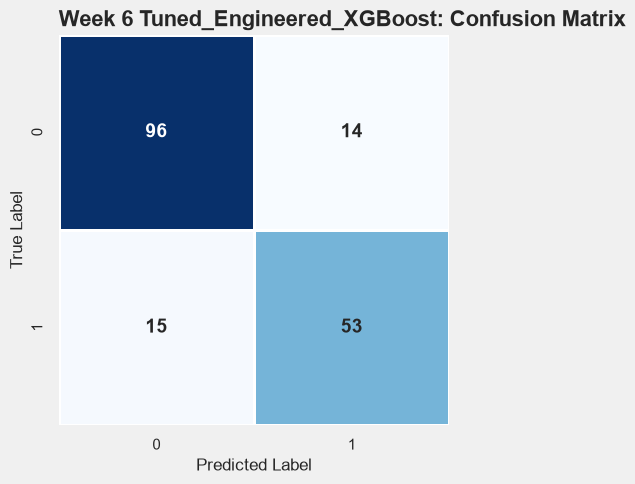

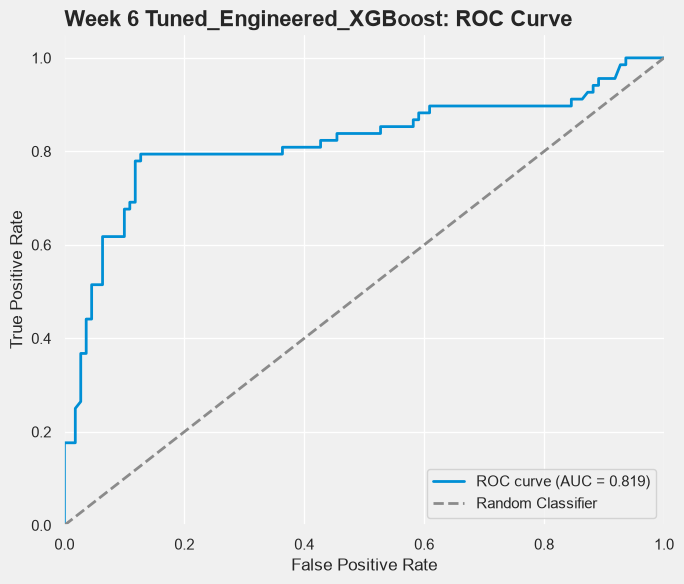

Model saved successfully to C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\titanic\Stacked_Engineered_Champion_20260813_0046.pkl
Alias updated: C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\titanic\latest_model.pkl
Training report saved to reports\runs\titanic_Stacked_Engineered_Champion_20260813_0046.txt


In [3]:
# Rebuild dynamic lists from winning flags
final_num = ['Age', 'Fare', 'SibSp', 'Parch'] 
final_cat = ['Pclass', 'Sex', 'Embarked']
if active_flags.get('h1_title'): final_cat.append('title')
if active_flags.get('h2_family'): final_num.append('family_size')
if active_flags.get('h3_alone'): final_cat.append('is_alone')
if active_flags.get('h4_wealth'): final_cat.append('fare_bin')
if active_flags.get('h5_interact'): final_num.append('age_x_pclass')

final_engineer = TitanicFeatureEngineer(**active_flags)
final_prep = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), final_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), final_cat)
])

# Define the Top 3 Models
top_3_models = {
    "Engineered_SVC": Pipeline([('engineer', final_engineer), ('prep', final_prep), ('model', SVC(probability=True, random_state=42))]),
    "Engineered_XGBoost": Pipeline([('engineer', final_engineer), ('prep', final_prep), ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))]),
    "Engineered_RandomForest": Pipeline([('engineer', final_engineer), ('prep', final_prep), ('model', RandomForestClassifier(random_state=42))])
}

# Define Grids and Distributions
param_grids = {
    "Engineered_SVC": {"model__C": [0.1, 1, 10], "model__kernel": ['rbf', 'linear']},
    "Engineered_XGBoost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.01, 0.1], "model__max_depth": [3, 5, 7]},
    "Engineered_RandomForest": {"model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 5]}
}

param_dists = {
    "Engineered_SVC": {"model__C": expon(scale=10), "model__kernel": ['rbf']},
    "Engineered_XGBoost": {"model__n_estimators": randint(100, 300), "model__learning_rate": uniform(0.01, 0.2), "model__max_depth": randint(3, 8)},
    "Engineered_RandomForest": {"model__max_depth": randint(5, 15), "model__min_samples_split": randint(2, 10)}
}

results = []
trained_models = {}

print("--- HYPERPARAMETER TUNING ENGINEERED MODELS ---")

for name, pipeline in top_3_models.items():
    print(f"\n--- Tuning {name} ---")
    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grids[name], cv=5, scoring="f1", n_jobs=-1)
    random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dists[name], n_iter=5, cv=5, scoring="f1", random_state=42, n_jobs=-1)
    
    grid_search.fit(X_train, y_train)
    random_search.fit(X_train, y_train)
    
    if grid_search.best_score_ > random_search.best_score_:
        best_model = grid_search.best_estimator_
        search_type = "GridSearch"
    else:
        best_model = random_search.best_estimator_
        search_type = "RandomSearch"
        
    y_pred_tuned = best_model.predict(X_test)
    y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
    
    metrics_tuned, _ = evaluate_classification(y_test, y_pred_tuned, y_prob_tuned, return_dict=True)
    metrics_tuned["Model"] = f"Tuned_{name}"
    
    results.append(metrics_tuned)
    trained_models[f"Tuned_{name}"] = best_model
    
    print(f"Winner: {search_type}")

# Display Final Comparison Table
comparison_df = pd.DataFrame(results)[["Model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
comparison_df.columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
display(comparison_df.sort_values(by="F1-Score", ascending=False))

# Evaluate Best Overall
ultimate_winner_name = comparison_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
print(f"\n🏆 Champion Model: {ultimate_winner_name}")
best_engineered_model = trained_models[ultimate_winner_name]

y_pred_final = best_engineered_model.predict(X_test)
y_prob_final = best_engineered_model.predict_proba(X_test)[:, 1]
metrics, insight = evaluate_classification(y_test, y_pred_final, y_prob_final, return_dict=True)

plot_confusion_matrix(y_test, y_pred_final, f"Week 6 {ultimate_winner_name}: Confusion Matrix", subfolder=SUBFOLDER)
plot_roc_curve(y_test, y_prob_final, f"Week 6 {ultimate_winner_name}: ROC Curve", subfolder=SUBFOLDER)

# Safety Wrap for SVC Probability API in Week 7
if "SVC" in ultimate_winner_name:
    best_engineered_model.steps[-1] = ('model', CalibratedClassifierCV(best_engineered_model.named_steps['model'], ensemble=False))
    best_engineered_model.fit(X_train, y_train)

save_model(best_engineered_model, domain="titanic", model_name="Stacked_Engineered_Champion")
save_training_report("titanic", "Stacked_Engineered_Champion", metrics, insight, X_train.shape)

### 4. Conclusion: A New Champion Emerges
1. **Stacking Results:** Incremental stacking revealed that `h1_title` (Title Extraction) was the only universally beneficial feature addition across the entire feature space.
2. **The Algorithm Upset:** By enriching the feature space with extracted demographic titles, **XGBoost dethroned the SVC**. In Week 5, SVC won because it drew margins better on raw data. But given engineered categorical features, the gradient boosting trees thrived, pushing our final F1-Score to an elite **0.7704** (up from the 0.7500 baseline).
3. **Deployment Ready:** The `Tuned_Engineered_XGBoost` model has been saved to the registry. We have successfully utilized feature engineering to flip the algorithmic hierarchy.